In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
daily_sales = pd.read_csv(
    "../Data/processed/daily_sales_features.csv"
)


In [3]:
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])

In [4]:
daily_sales['Revenue']=(
    daily_sales['Quantity']
)

In [5]:
top_skus = (
    daily_sales
    .groupby('StockCode')['Revenue']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

top_skus

StockCode
85123A    54027.0
21212     45248.0
85099B    40936.0
84879     40283.0
84991     28730.0
20725     26114.0
21977     25953.0
22197     24812.0
84077     24221.0
21232     23250.0
22178     20423.0
21498     20130.0
84946     19828.0
84755     19559.0
22386     18823.0
22423     18747.0
22383     18283.0
21213     18100.0
21080     17992.0
22469     17672.0
Name: Revenue, dtype: float64

In [6]:
selected_sku = top_skus.index[0]

sku_df = daily_sales[
    daily_sales['StockCode']
    == selected_sku
]

In [7]:
sku_ts = (
    sku_df
    .groupby(
        'InvoiceDate'
    )['Quantity']
    .sum()
)

In [8]:
sku_ts=sku_ts.sort_index()

In [9]:
from statsmodels.tsa.seasonal import STL

In [10]:
stl = STL(
    sku_ts,
    period=7
)

result = stl.fit()

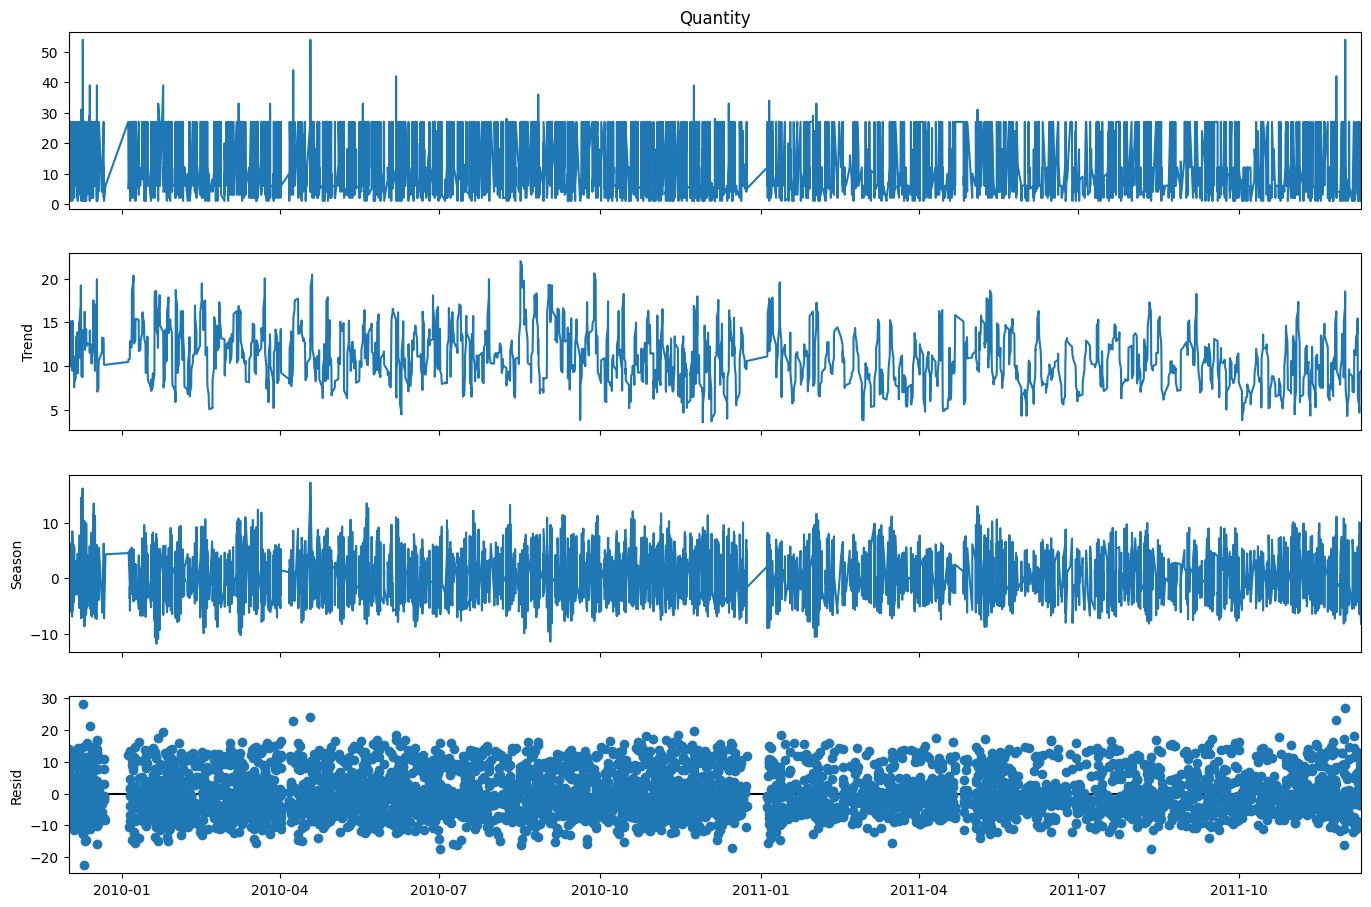

In [11]:
fig = result.plot()

fig.set_size_inches(
    15,
    10
)

plt.show()

In [12]:
weekly = (
    sku_ts
    .resample('W')
    .sum()
)

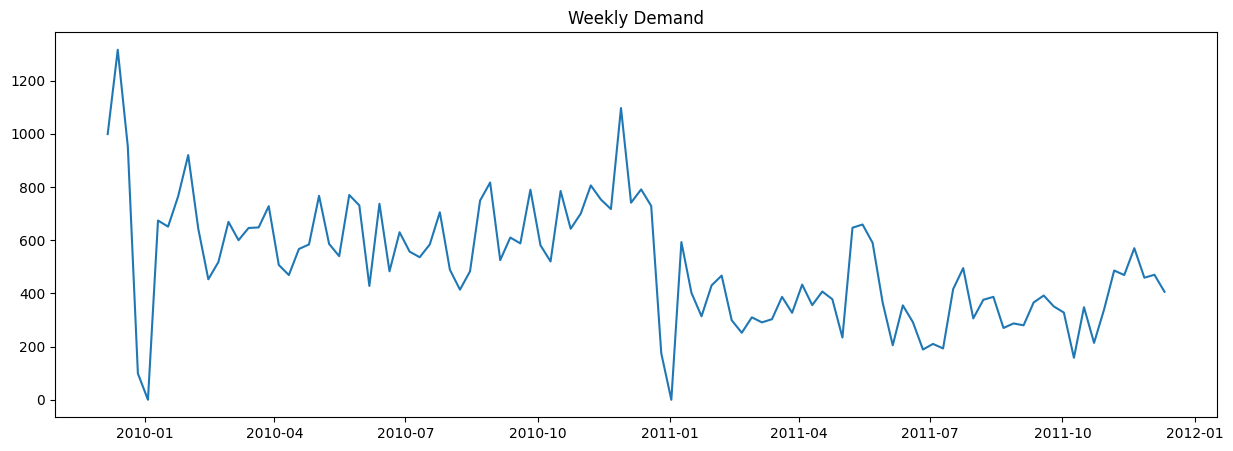

In [13]:
plt.figure(
    figsize=(15,5)
)

plt.plot(
    weekly
)

plt.title(
    "Weekly Demand"
)

plt.show()

In [14]:
sku_features = pd.DataFrame()

sku_features['sales']=sku_ts

sku_features['weekday']=(
    sku_features.index.weekday
)

sku_features['month']=(
    sku_features.index.month
)

In [15]:
sku_features.groupby(
    'weekday'
)['sales'].mean()

weekday
0    11.149233
1    12.511137
2    11.321386
3    11.411168
4    11.350238
5    12.500000
6     9.012165
Name: sales, dtype: float64

In [16]:
sku_features.groupby(
    'month'
)['sales'].mean()

month
1     12.343669
2     11.689320
3     10.886473
4     11.177778
5     11.748826
6     10.577465
7     11.332378
8     11.371429
9     11.885942
10     9.705314
11    10.015411
12    11.528517
Name: sales, dtype: float64

In [18]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

In [19]:
prophet_df = sku_ts.reset_index()

prophet_df.columns=[
    'ds',
    'y'
]

In [20]:
split=int(
    len(prophet_df)*0.8
)

train=prophet_df[:split]

test=prophet_df[split:]

In [21]:
param_grid = [

{
'cps':0.01,
'mode':'additive'
},

{
'cps':0.05,
'mode':'additive'
},

{
'cps':0.1,
'mode':'multiplicative'
},

{
'cps':0.5,
'mode':'multiplicative'
}

]

In [22]:
results=[]

In [23]:
for p in param_grid:

    model=Prophet(
        changepoint_prior_scale=
        p['cps'],

        seasonality_mode=
        p['mode']
    )

    model.fit(
        train
    )

    future=model.make_future_dataframe(
        periods=len(test)
    )

    forecast=model.predict(
        future
    )

    pred=forecast[
        'yhat'
    ].tail(
        len(test)
    )

    mae=mean_absolute_error(
        test['y'],
        pred
    )

    results.append(
        [p,mae]
    )

17:17:32 - cmdstanpy - INFO - Chain [1] start processing
17:17:33 - cmdstanpy - INFO - Chain [1] done processing
17:17:34 - cmdstanpy - INFO - Chain [1] start processing
17:17:35 - cmdstanpy - INFO - Chain [1] done processing
17:17:36 - cmdstanpy - INFO - Chain [1] start processing
17:17:36 - cmdstanpy - INFO - Chain [1] done processing
17:17:38 - cmdstanpy - INFO - Chain [1] start processing
17:17:39 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
results

[[{'cps': 0.01, 'mode': 'additive'}, 6.633084272620492],
 [{'cps': 0.05, 'mode': 'additive'}, 6.6296385559545525],
 [{'cps': 0.1, 'mode': 'multiplicative'}, 6.848926432533458],
 [{'cps': 0.5, 'mode': 'multiplicative'}, 7.013255691949805]]

In [25]:
best=min(
    results,
    key=lambda x:x[1]
)

best

[{'cps': 0.05, 'mode': 'additive'}, 6.6296385559545525]

In [ ]:
best_params=best[0]

final_model=Prophet(

changepoint_prior_scale=
best_params['cps'],

seasonality_mode=
best_params['mode']

)

final_model.fit(
    prophet_df
)